# Lab 5 · Diffusion FWI — Interactive Generation Notebook

**Goal:** Generate probabilistic subsurface velocity models from seismic observations using a pre-trained conditional diffusion model.

| What you’ll do | How |
|---|---|
| Explore seismic input data | Sample + source selector widgets |
| Inspect the ground-truth velocity model | Interactive visualisation |
| Load a pre-trained `DiffusionFWINet` | `physicsnemo.Module.from_checkpoint` |
| Run ensemble generation (CPU ~2 min, GPU seconds) | Zero-shot conditional sampling |
| Visualise predictions & uncertainty | Pre-generated results included |

> **No GPU required for visualisation.** Pre-generated outputs are bundled in `outputs_cond/`.

In [ ]:
# SPDX-FileCopyrightText: Copyright (c) 2023 - 2026 NVIDIA CORPORATION & AFFILIATES.
# SPDX-License-Identifier: Apache-2.0

## 1 · Setup

In [1]:
import sys
from pathlib import Path
from functools import partial

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import torch
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from einops import rearrange

from physicsnemo import Module

# StackedRandomGenerator — with fallback for older or partial physicsnemo installs
try:
    from physicsnemo.diffusion.utils import StackedRandomGenerator
except (ImportError, ModuleNotFoundError):
    class StackedRandomGenerator:
        def __init__(self, device, seeds):
            self.generators = [
                torch.Generator(device=device).manual_seed(int(s)) for s in seeds
            ]
        def randn(self, shape, device=None, dtype=torch.float32):
            if device is None:
                device = self.generators[0].device
            return torch.stack([
                torch.randn(shape[1:], generator=g, device=device, dtype=dtype)
                for g in self.generators
            ])
    print("⚠ Using local StackedRandomGenerator (physicsnemo.diffusion.utils not found)")

# deepwave — optional, only needed for physics-informed DPS
try:
    import deepwave
    DEEPWAVE_AVAILABLE = True
except ImportError:
    DEEPWAVE_AVAILABLE = False

from utils.preconditioning import edm_precond
from utils.diffusion import DiffusionAdapter, ModelBasedGuidance, EDMStochasticSampler
from utils.nn import DiffusionFWINet

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Imports OK  |  Device: {DEVICE}  |  PyTorch: {torch.__version__}')
print(f'  deepwave: {"available ✓" if DEEPWAVE_AVAILABLE else "not installed (physics-informed DPS disabled)"}')

✓ Imports OK  |  Device: cpu  |  PyTorch: 2.10.0
  deepwave: not installed (physics-informed DPS disabled)


## 2 · Configuration

Choose a sample, checkpoint, and generation settings using the widgets below.

In [2]:
CHECKPOINT_DIR = NOTEBOOK_DIR / 'checkpoints' / 'conditional'
OUTPUT_DIR     = NOTEBOOK_DIR / 'outputs_cond'

checkpoint_options = sorted([f.name for f in CHECKPOINT_DIR.glob('*.mdlus')]) or ['(none found)']
sample_options     = sorted([d.name for d in OUTPUT_DIR.iterdir() if d.is_dir() and d.name.startswith('sample_')])

w_checkpoint = widgets.Dropdown(
    options=checkpoint_options,
    description='Checkpoint:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='420px'),
)
w_sample = widgets.Dropdown(
    options=sample_options,
    value=sample_options[0] if sample_options else None,
    description='Sample:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='420px'),
)
w_sources = widgets.IntSlider(
    value=3, min=1, max=12, step=1,
    description='Sources shown:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='420px'),
)
w_ensembles = widgets.IntSlider(
    value=4, min=1, max=16, step=1,
    description='Ensembles (live):',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='420px'),
)
display(widgets.VBox([
    widgets.HTML('<b>Model &amp; Data</b>'),
    w_checkpoint, w_sample,
    widgets.HTML('<b>Display &amp; Generation</b>'),
    w_sources, w_ensembles,
]))

## 3 · Load & Visualise Input Data

The seismic recordings ($v_x$, $v_z$) are the conditioning signal fed to the diffusion model.

In [3]:
def load_sample(name):
    return dict(np.load(OUTPUT_DIR / name / 'numpy' / 'data.npz', allow_pickle=True))

sample_data = load_sample(w_sample.value)
vx_np = sample_data['vx'][0]   # (nb_shots, T, W)
vz_np = sample_data['vz'][0]
print(f"Loaded '{w_sample.value}' — seismic shape: {vx_np.shape}  (shots × time × receivers)")

Loaded 'sample_0' — seismic shape: (5, 1000, 80)  (shots × time × receivers)


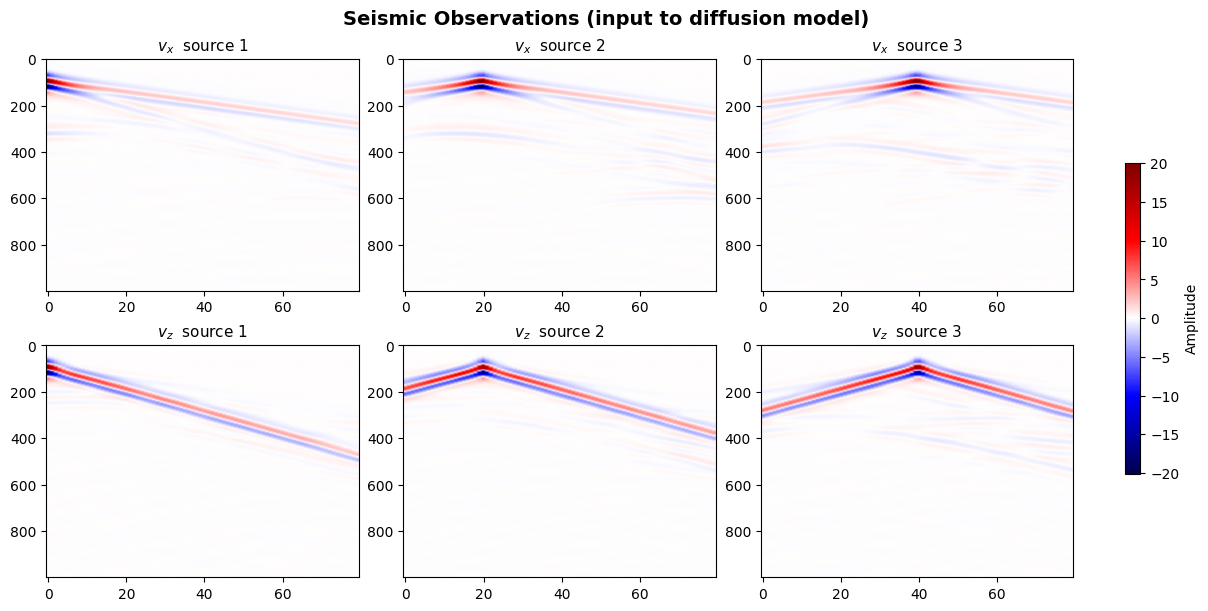

In [4]:
def plot_seismic(vx, vz, n_sources):
    n = min(n_sources, vx.shape[0])
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 6), constrained_layout=True)
    fig.suptitle('Seismic Observations (input to diffusion model)', fontsize=14, fontweight='bold')
    if n == 1: axes = axes[:, np.newaxis]
    vmax = max(np.abs(vx).max(), np.abs(vz).max()) * 0.8
    kw = dict(aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax)
    for i in range(n):
        im = axes[0, i].imshow(vx[i], **kw)
        axes[0, i].set_title(f'$v_x$  source {i+1}', fontsize=11)
        axes[1, i].imshow(vz[i], **kw)
        axes[1, i].set_title(f'$v_z$  source {i+1}', fontsize=11)
    plt.colorbar(im, ax=axes, label='Amplitude', shrink=0.6)
    plt.show()

plot_seismic(vx_np, vz_np, w_sources.value)

### Ground-Truth Velocity Model

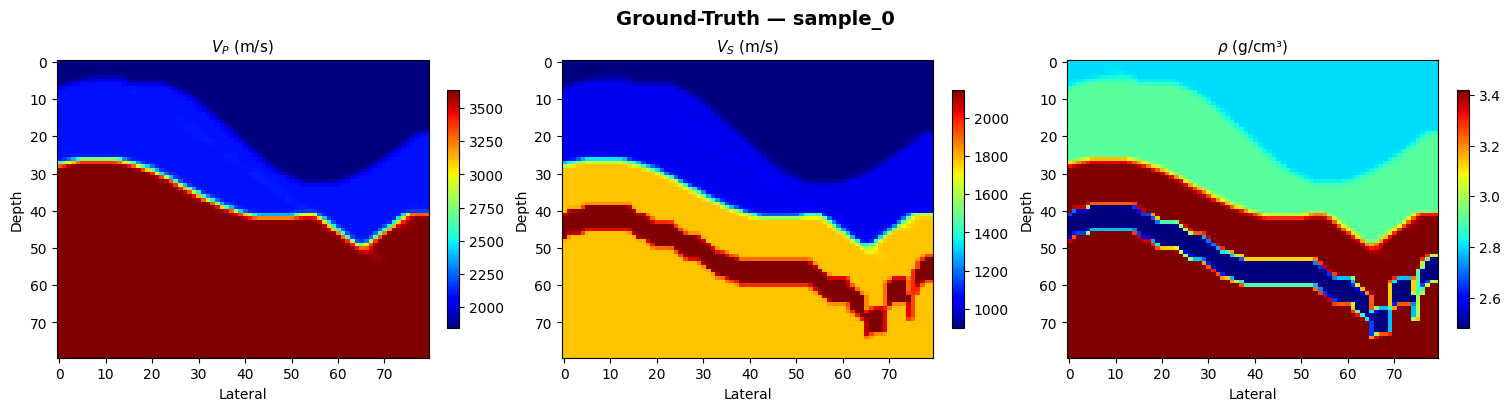

In [5]:
def plot_velocity_model(data, title='Velocity Model'):
    fields = [('vp_true', '$V_P$ (m/s)'), ('vs_true', '$V_S$ (m/s)'), ('rho_true', r'$\rho$ (g/cm³)')]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for ax, (key, lbl) in zip(axes, fields):
        arr = data[key][0, 0]   # (batch=1, channel=1, H, W) -> (H, W)
        im = ax.imshow(arr, cmap='jet', aspect='auto', origin='upper')
        ax.set_title(lbl, fontsize=11)
        ax.set_xlabel('Lateral'); ax.set_ylabel('Depth')
        plt.colorbar(im, ax=ax, shrink=0.8)
    plt.show()

plot_velocity_model(sample_data, title=f'Ground-Truth — {w_sample.value}')

## 4 · Load Diffusion Model

In [ ]:
ckpt_path = CHECKPOINT_DIR / w_checkpoint.value
print(f'Loading: {ckpt_path}')

diffusion_net = Module.from_checkpoint(str(ckpt_path))
diffusion_net = diffusion_net.to(DEVICE).eval()
n_params = sum(p.numel() for p in diffusion_net.parameters())
print(f'✓ Loaded  |  {n_params:,} parameters  |  device: {DEVICE}')

try:
    from physicsnemo.diffusion.noise_schedulers import EDMNoiseScheduler
    from physicsnemo.diffusion.samplers import sample as edm_sample
    noise_scheduler = EDMNoiseScheduler(sigma_min=0.002, sigma_max=80.0, sigma_data=0.5)
    USE_UPSTREAM_SAMPLER = True
    print('✓ EDMNoiseScheduler ready  |  20 steps, σ ∈ [0.002, 80]')
except ImportError:
    USE_UPSTREAM_SAMPLER = False
    print('✓ Local EDMStochasticSampler will be used  |  20 steps, σ ∈ [0.002, 80]')

# ── Normalization stats (z-score) derived from the E-FWI training dataset ──────
# Target variables: vp (m/s), vs (m/s), rho (g/cm³)
STATS_MEAN = torch.tensor([2966.5, 1579.0, 2.797])
STATS_STD  = torch.tensor([ 881.8,  502.9, 0.504])

# Seismic conditioning: vx/vz stored in physical units; model expects z-score.
# Std computed using the upstream compute_stats.py formula where nb_points = H*W
# (spatial dims only), so each of the n_shots=5 shots is counted independently.
# This gives std_eff = sqrt(n_shots) * std_simple = sqrt(5) * {0.724, 0.884}.
COND_MEAN_VX, COND_STD_VX = 0.0, 1.618   # sqrt(5) * 0.724
COND_MEAN_VZ, COND_STD_VZ = 0.0, 1.977   # sqrt(5) * 0.884

## 5 · Generate Predictions

**Pre-generated** loads bundled outputs instantly.  
**Live inference** runs the diffusion model (~2 min on CPU, seconds on GPU).

In [7]:
w_mode = widgets.ToggleButtons(
    options=['Pre-generated (instant)', 'Live inference'],
    description='Mode:',
    style={'description_width': '80px', 'button_width': '200px'},
)
display(w_mode)

ToggleButtons(description='Mode:', options=('Pre-generated (instant)', 'Live inference'), style=ToggleButtonsS…

In [ ]:
if w_mode.value == 'Pre-generated (instant)':
    print(f"Loading pre-generated predictions for '{w_sample.value}'...")
    pred = load_sample(w_sample.value)
    def _load_var(key, fallback):
        arr = torch.from_numpy(pred.get(key, pred[fallback][None])).float()
        return arr.squeeze(1) if arr.ndim == 4 and arr.shape[1] == 1 else arr
    vp  = _load_var('vp_ensemble',  'vp_mean')
    vs  = _load_var('vs_ensemble',  'vs_mean')
    rho = _load_var('rho_ensemble', 'rho_mean')
    x_pred = torch.stack([vp, vs, rho], dim=1)  # (N, 3, H, W) — already physical units
    print(f'✓ Loaded {x_pred.shape[0]} ensemble members, shape {tuple(x_pred.shape)}')
else:
    print(f'Running live inference ({w_ensembles.value} ensembles) on {DEVICE}...')
    vx_t = torch.from_numpy(sample_data['vx']).float().to(DEVICE)
    vz_t = torch.from_numpy(sample_data['vz']).float().to(DEVICE)

    # Normalize seismic conditioning — stored in physical units, model expects z-score
    vx_norm_cond = (vx_t - COND_MEAN_VX) / COND_STD_VX
    vz_norm_cond = (vz_t - COND_MEAN_VZ) / COND_STD_VZ
    y_cond = torch.cat([vx_norm_cond, vz_norm_cond], dim=1)   # (1, 2*shots, T, W)

    N = w_ensembles.value
    H, W = sample_data['vp_true'].shape[-2], sample_data['vp_true'].shape[-1]
    seeds = list(range(N))
    rng = StackedRandomGenerator(DEVICE, seeds)

    _sigma_data = 0.5

    def _precond_x0(x, sigma, y):
        """Apply EDM preconditioning and return denoised x0 estimate."""
        c_skip = _sigma_data**2 / (sigma**2 + _sigma_data**2)
        c_out  = sigma * _sigma_data / (sigma**2 + _sigma_data**2).sqrt()
        c_in   = 1 / (_sigma_data**2 + sigma**2).sqrt()
        c_noise = sigma.log() / 4
        F_x = diffusion_net(
            c_in.view(-1, 1, 1, 1) * x,
            c_noise.flatten(),
            condition=y[:x.shape[0]],
        )
        return c_skip.view(-1, 1, 1, 1) * x + c_out.view(-1, 1, 1, 1) * F_x

    if USE_UPSTREAM_SAMPLER:
        _y = y_cond.expand(N, -1, -1, -1).to(DEVICE)

        def x0_predictor(x, t):
            return _precond_x0(x, t, _y)

        denoiser = noise_scheduler.get_denoiser(x0_predictor=x0_predictor, denoising_type="ode")
        t_steps = noise_scheduler.timesteps(20, device=DEVICE)
        x_T = noise_scheduler.sigma(t_steps[0]) * rng.randn((N, 3, H, W), device=DEVICE)
        with torch.inference_mode():
            x_norm = edm_sample(denoiser=denoiser, xN=x_T, noise_scheduler=noise_scheduler,
                                num_steps=20, solver="heun", time_steps=t_steps).cpu()
    else:
        _y_exp = y_cond.expand(N, -1, -1, -1)

        def model_fn(x, sigma, cond):
            return _precond_x0(x, sigma, cond.get('y', _y_exp))

        local_sampler = EDMStochasticSampler(model=model_fn, num_steps=20, sigma_min=0.002, sigma_max=80.0)
        x_init = rng.randn((N, 3, H, W), device=DEVICE)
        with torch.no_grad():
            x_norm = local_sampler(x_init, cond={'y': _y_exp}).cpu()

    # Denormalize from training space to physical units
    std  = STATS_STD.view(1, 3, 1, 1)
    mean = STATS_MEAN.view(1, 3, 1, 1)
    x_pred = x_norm * std + mean   # (N, 3, H, W)

    print(f'✓ Generated {x_pred.shape[0]} ensemble members, shape {tuple(x_pred.shape)}')
    print(f'  vp  range: [{x_pred[:,0].min():.0f}, {x_pred[:,0].max():.0f}] m/s')
    print(f'  vs  range: [{x_pred[:,1].min():.0f}, {x_pred[:,1].max():.0f}] m/s')
    print(f'  rho range: [{x_pred[:,2].min():.3f}, {x_pred[:,2].max():.3f}] g/cm³')

## 6 · Predictions vs Ground Truth

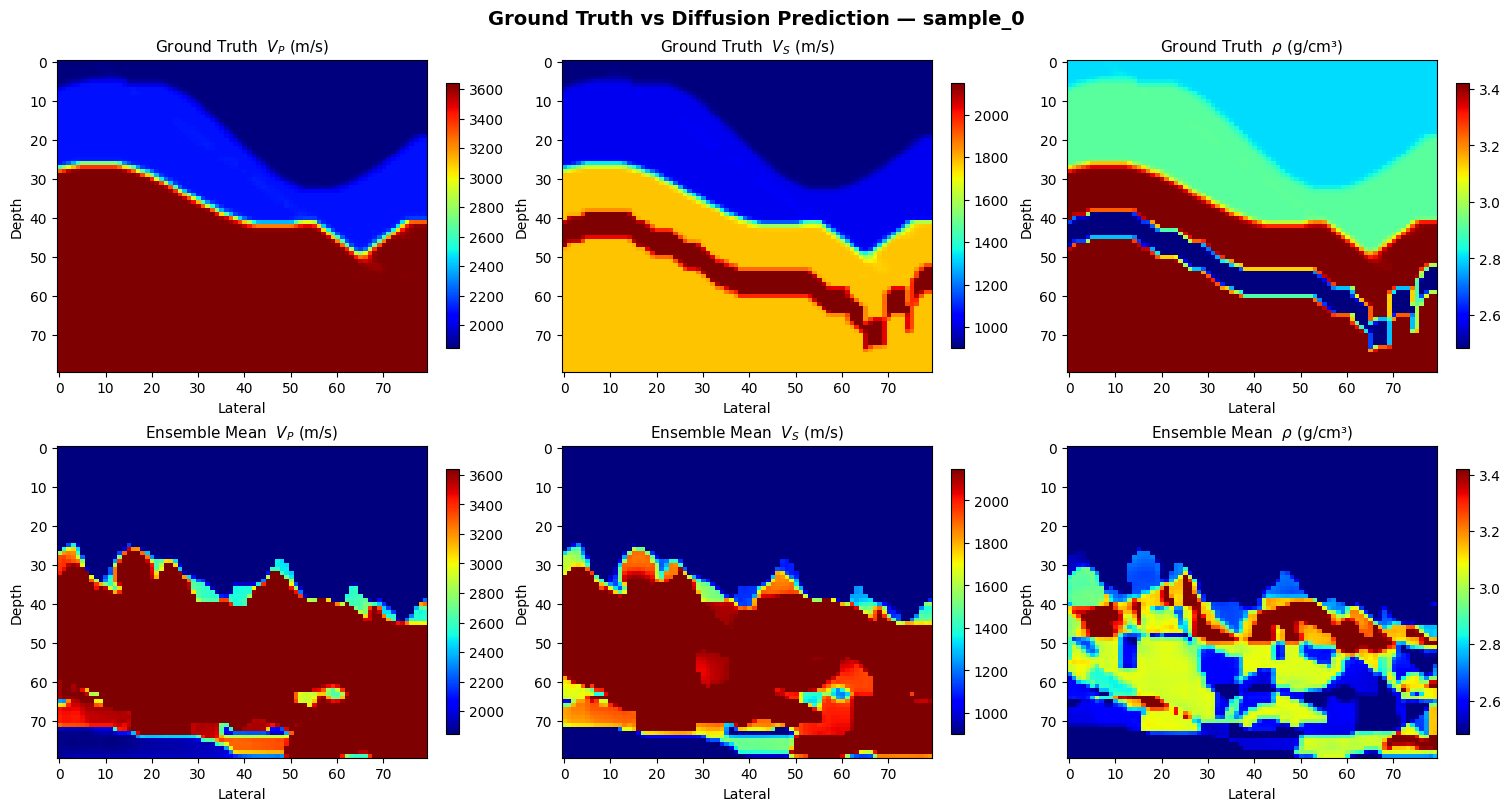

In [10]:
def plot_predictions(sample_data, x_pred, title=''):
    fields = [('vp_true', '$V_P$ (m/s)', 0), ('vs_true', '$V_S$ (m/s)', 1), ('rho_true', r'$\rho$ (g/cm³)', 2)]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
    fig.suptitle(f'Ground Truth vs Diffusion Prediction — {title}', fontsize=14, fontweight='bold')
    for col, (key, lbl, idx) in enumerate(fields):
        gt   = sample_data[key][0, 0]       # (H, W)
        pred = x_pred[:, idx].mean(0).numpy()  # (H, W)
        kw = dict(cmap='jet', aspect='auto', origin='upper', vmin=gt.min(), vmax=gt.max())
        plt.colorbar(axes[0, col].imshow(gt, **kw), ax=axes[0, col], shrink=0.85)
        axes[0, col].set_title(f'Ground Truth  {lbl}', fontsize=11)
        plt.colorbar(axes[1, col].imshow(pred, **kw), ax=axes[1, col], shrink=0.85)
        axes[1, col].set_title(f'Ensemble Mean  {lbl}', fontsize=11)
        for ax in axes[:, col]:
            ax.set_xlabel('Lateral'); ax.set_ylabel('Depth')
    plt.show()

plot_predictions(sample_data, x_pred, title=w_sample.value)

## 7 · Ensemble Uncertainty

Variance across ensemble members highlights where the model is uncertain — typically at sharp geological boundaries.

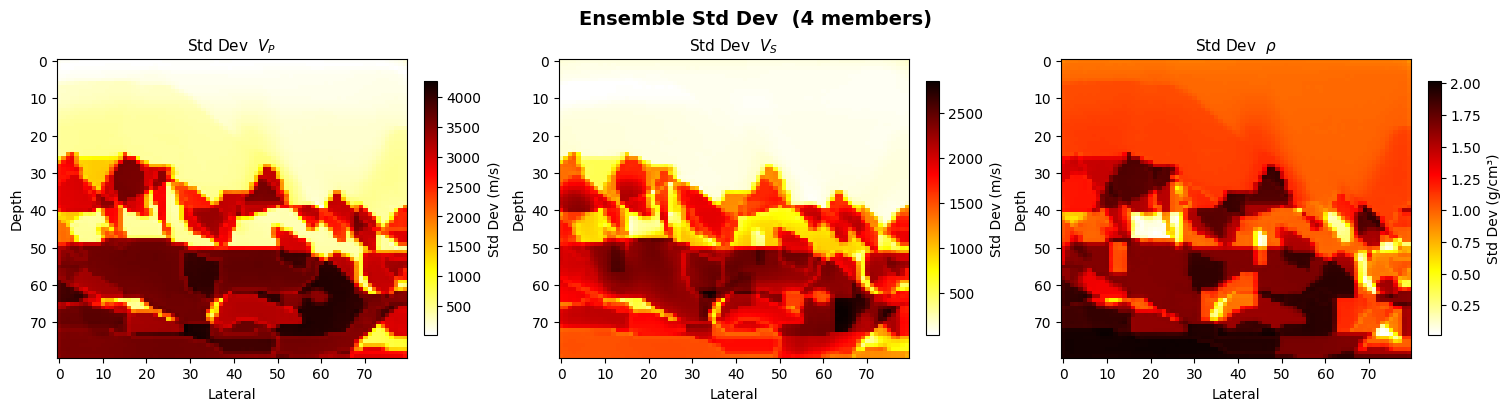

In [11]:
def plot_uncertainty(x_pred):
    std = x_pred.std(dim=0).numpy()  # (3, H, W) — std in physical units
    labels  = ['$V_P$',  '$V_S$',  r'$\rho$']
    units   = ['m/s',    'm/s',    'g/cm³']
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    fig.suptitle(f'Ensemble Std Dev  ({x_pred.shape[0]} members)', fontsize=14, fontweight='bold')
    for ax, s, lbl, unit in zip(axes, std, labels, units):
        im = ax.imshow(s, cmap='hot_r', aspect='auto', origin='upper')
        ax.set_title(f'Std Dev  {lbl}', fontsize=11)
        ax.set_xlabel('Lateral'); ax.set_ylabel('Depth')
        plt.colorbar(im, ax=ax, shrink=0.85, label=f'Std Dev ({unit})')
    plt.show()

plot_uncertainty(x_pred)

## 8 · Quantitative Metrics

In [56]:
def report_metrics(sample_data, x_pred):
    rows = [('vp', '$V_P$'), ('vs', '$V_S$'), ('rho', r'$\rho$')]
    print(f"{'Variable':<8}  {'RMSE':>10}  {'MAE':>10}  {'R²':>8}")
    print('-' * 44)
    for i, (key, lbl) in enumerate(rows):
        gt   = torch.from_numpy(sample_data[f'{key}_true'][0, 0]).float()  # (H, W)
        pred = x_pred[:, i].mean(0)                                         # (H, W)
        rmse = (pred - gt).pow(2).mean().sqrt().item()
        mae  = (pred - gt).abs().mean().item()
        ss_res = (pred - gt).pow(2).sum().item()
        ss_tot = (gt - gt.mean()).pow(2).sum().item()
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')
        print(f'{lbl:<8}  {rmse:>10.2f}  {mae:>10.2f}  {r2:>8.4f}')

report_metrics(sample_data, x_pred)

Variable        RMSE         MAE        R²
--------------------------------------------
$V_P$         283.99      217.26    0.8821
$V_S$         197.36      145.54    0.8022
$\rho$          0.82        0.77   -5.7597


## Summary

| Step | What happened |
|---|---|
| **Input** | Seismic wavefields $v_x, v_z$ (shots × time × receivers) |
| **Model** | Conditional `DiffusionFWINet` trained on elastic wave simulations |
| **Output** | Ensemble of velocity models $(V_P, V_S, \\rho)$ |
| **Uncertainty** | Per-pixel ensemble variance highlights uncertain regions |

**Next steps:**
- Try a different sample with the **Sample** dropdown above
- Increase **Ensembles** for a richer uncertainty estimate
- Install `deepwave` and switch to *Live inference* to run physics-informed DPS

📌 **Upstream example:** `examples/geophysics/diffusion_fwi/` in the [PhysicsNeMo repo](https://github.com/NVIDIA/physicsnemo)